<center>
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="300" alt="cognitiveclass.ai logo">
</center>


# **Performing Linear Regression in Keras**


During the pandemic, a bike-sharing service had suffered considerable losses in their revenues. As a data scientist on the analytics team, you have been tasked to help with coming up with a business plan to accelerate the company's revenue. The first step in this process is to understand the current demand for shared bikes among the people in the city.

You recommend that the team first try to understand the factors on which the demand for these shared bikes depends. In this lab, we will perform a linear regression to predict the count of total rental bikes, and understand the impact of some contributing factors.

<center>
    <img src="https://live.staticflickr.com/36/84666910_b889a5ad04_b.jpg" width="300" alt="tulip flower">
<center>


## __Table of Contents__

1. [Objectives](#toc-objectives)
2. [Setup](#toc-setup)
    1. [Installing Required Libraries](#toc-installing-required-libraries)
    2. [Importing Required Libraries](#toc-importing-required-libraries)
3. [Linear Regression](#toc-linear-regression)
    1. [Bike Sharing Dataset](#toc-bike-sharing-dataset)
    2. [Clean the data](#toc-clean-the-data)
    3. [Data exploration: Bivariate analysis](#toc-data-exploration-bivariate-analysis)
    4. [Data exploration: Multivariate analysis](#toc-data-exploration-multivariate-analysis)
    5. [Data exploration: Heatmap of columns](#toc-data-exploration-heatmap-of-columns)
    6. [Split the data into training and test sets](#toc-split-the-data-into-training-and-test-sets)
    7. [Split features from labels](#toc-split-features-from-labels)
    8. [Normalization](#toc-normalization)
    9. [Linear regression with a single input](#toc-linear-regression-with-a-single-input)
    10. [Linear regression with multiple inputs](#toc-linear-regression-with-multiple-inputs)
4. [Using Neural Networks for Linear Regression](#toc-using-neural-networks-for-linear-regression)
5. [Exercises](#toc-exercises)
    1. [Exercise 1 - Loading a dataset (Auto MPG)](#toc-exercise-1-loading-a-dataset-auto-mpg))
    2. [Exercise 2 - Clean the data](#toc-exercise-2-clean-the-data)
    3. [Exercise 3 - Split the data](#toc-exercise-3-split-the-data)
    4. [Exercise 4 - Create a normalization layer](#toc-exercise-4-create-a-normalization-layer)
    5. [Exercise 5 - Linear regression with multiple inputs](#toc-exercise-5-linear-regression-with-multiple-inputs)


## **Objectives** <a id="toc-objectives"></a>

After completing this lab you will be able to:

 - Build single-variable and multi-variable linear regression models using Keras.
 - Use linear regression to predict a continuous target variable given a set of input features


----


## **Setup** <a id="toc-setup"></a>


For this lab, we will be using the following libraries:

*   [`pandas`](https://pandas.pydata.org/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0187ENSkillsNetwork31430127-2021-01-01) for managing the data.
*   [`numpy`](https://numpy.org/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0187ENSkillsNetwork31430127-2021-01-01) for mathematical operations.
*   [`sklearn`](https://scikit-learn.org/stable/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0187ENSkillsNetwork31430127-2021-01-01) for machine learning and machine-learning-pipeline related functions.
*   [`seaborn`](https://seaborn.pydata.org/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0187ENSkillsNetwork31430127-2021-01-01) for visualizing the data.
*   [`matplotlib`](https://matplotlib.org/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0187ENSkillsNetwork31430127-2021-01-01) for additional plotting tools.


### **Installing Required Libraries** <a id="toc-installing-required-libraries"></a>

The following required libraries are pre-installed in the Skills Network Labs environment. However, if you run these notebook commands in a different Jupyter environment (e.g. Watson Studio or Ananconda), you will need to install these libraries by removing the `#` sign before `!pip` in the following code cell.


In [84]:
# All Libraries required for this lab are listed below. The libraries pre-installed on Skills Network Labs are commented.
# !mamba install -qy pandas==1.3.4 numpy==1.21.4 seaborn==0.9.0 matplotlib==3.5.0 scikit-learn==0.20.1
# Note: If your environment doesn't support "!mamba install", use "!pip install"

The following required libraries are __not__ pre-installed in the Skills Network Labs environment. __You will need to run the following cell__ to install them:


In [ ]:
# %%capture
#!pip install --upgrade tensorflow

### **Importing Required Libraries** <a id="toc-importing-required-libraries"></a>

_We recommend you import all required libraries in one place, as follows:_


In [86]:
import warnings
warnings.simplefilter('ignore')

import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2' 

import numpy as np
import pandas as pd
from itertools import accumulate
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn import metrics
from sklearn.metrics import mean_squared_error

sns.set_context('notebook')
sns.set_style('white')

## **Linear Regression** <a id="toc-linear-regression"></a>



Linear Regression is a supervised learning method used to model the relationship between a dependent variable $Y$ and one or more independent variables $X$. The goal is to predict the value of $Y$ from the input features.

For a simple linear regression model with one input feature, the relationship can be written as:

$$
Y = \theta_0 + \theta_1 X
$$

where:

- $ \theta_0 $ is the intercept
- $ \theta_1 $ is the coefficient (weight) of the feature

The model works by finding the best values of $ \theta_0 $ and $ \theta_1 $ so that the predicted values are as close as possible to the true values.

To achieve this, the model minimizes a **loss function**, which measures the prediction error. During training, the coefficients are repeatedly updated using an optimization method such as **gradient descent**. The updates continue until the loss function stops decreasing and the model converges to a minimum error.

When multiple input features are used, the model becomes **Multiple Linear Regression**. If there are $n$ input features, the model can be written as:

$$
Y = \theta_0 + \theta_1 X_1 + \theta_2 X_2 + \cdots + \theta_n X_n
$$

In matrix form, the dataset is represented as an $m \times n$ feature matrix, where:

- $m$ is the number of samples
- $n$ is the number of features

Multiple Linear Regression allows the model to learn how several variables together influence the target variable.

### **Bike Sharing Dataset** <a id="toc-bike-sharing-dataset"></a>

We will use the Bike Sharing Dataset from the [UCI Machine Learning Repository](https://archive.ics.uci.edu/ml/datasets/Bike+Sharing+Dataset). The dataset contains information about hourly and daily bike rentals together with weather, seasonal, and calendar-related variables.

The dataset includes several time-related features such as:

- `dteday` : date  
- `season` : season of the year  
- `yr` : year (2011 or 2012)  
- `mnth` : month  
- `hr` : hour of the day  
- `weekday` : day of the week  
- `holiday` and `workingday` : whether the day is a holiday or working day  

Weather information is stored in the `weathersit` feature, which describes conditions ranging from clear skies to heavy rain or snow. Environmental variables include normalized temperature (`temp`), normalized feeling temperature (`atemp`), humidity (`hum`), and wind speed (`windspeed`).

The normalized temperature values are calculated as:

$$
temp = \frac{t - t_{min}}{t_{max} - t_{min}}
$$

where $t_{min} = -8^\circ C$ and $t_{max} = 39^\circ C$.

Similarly, the normalized feeling temperature is calculated as:

$$
atemp = \frac{t - t_{min}}{t_{max} - t_{min}}
$$

where $t_{min} = -16^\circ C$ and $t_{max} = 50^\circ C$.

The dataset also records bike rental counts, including `casual` users, `registered` users, and the total number of rentals `cnt`.

Download the dataset, and unzip the `Bike-Sharing-Dataset.zip` folder.


In [ ]:
import skillsnetwork

await skillsnetwork.prepare(
    "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML311-Coursera/labs/Module1/L2/data/Bike-Sharing-Dataset.zip",
    overwrite=True,
)

  0%|          | 0/3 [00:00<?, ?it/s]

Saved to '.'


We will be using the `day.csv` file.


In [ ]:
raw_dataset = pd.read_csv("day.csv")

Let's look at some samples rows from the dataset we loaded:


In [89]:
raw_dataset.sample(5)

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
248,249,2011-09-06,3,0,9,0,2,1,3,0.540000,0.515200,0.886957,0.343943,204,2506,2710
257,258,2011-09-15,3,0,9,0,4,1,2,0.577500,0.553671,0.709167,0.271146,428,3231,3659
659,660,2012-10-21,4,1,10,0,0,0,1,0.464167,0.456429,0.510000,0.166054,2132,4692,6824
318,319,2011-11-15,4,0,11,0,2,1,2,0.530000,0.507579,0.688750,0.199633,449,3746,4195
26,27,2011-01-27,1,0,1,0,4,1,1,0.195000,0.219700,0.687500,0.113837,15,416,431


### **Clean the data** <a id="toc-clean-the-data"></a>


Let us drop the `dteday` column as it is not numerical, and we already have some other date like features like `mnth`, `year` and `weekday`.

We will remove `instant` as it is just a row instance identifier.

We will also drop `registered` and `casual` as they are used to compute our target variable `cnt` and including them would result in data leakage.


In [ ]:
raw_dataset = raw_dataset.drop(
    columns=["dteday", "instant", "registered", "casual"]
)

### **Data exploration: Bivariate analysis** <a id="toc-data-exploration-bivariate-analysis"></a>


We will create scatterplots for a few numerical variables against the target variable `cnt`.


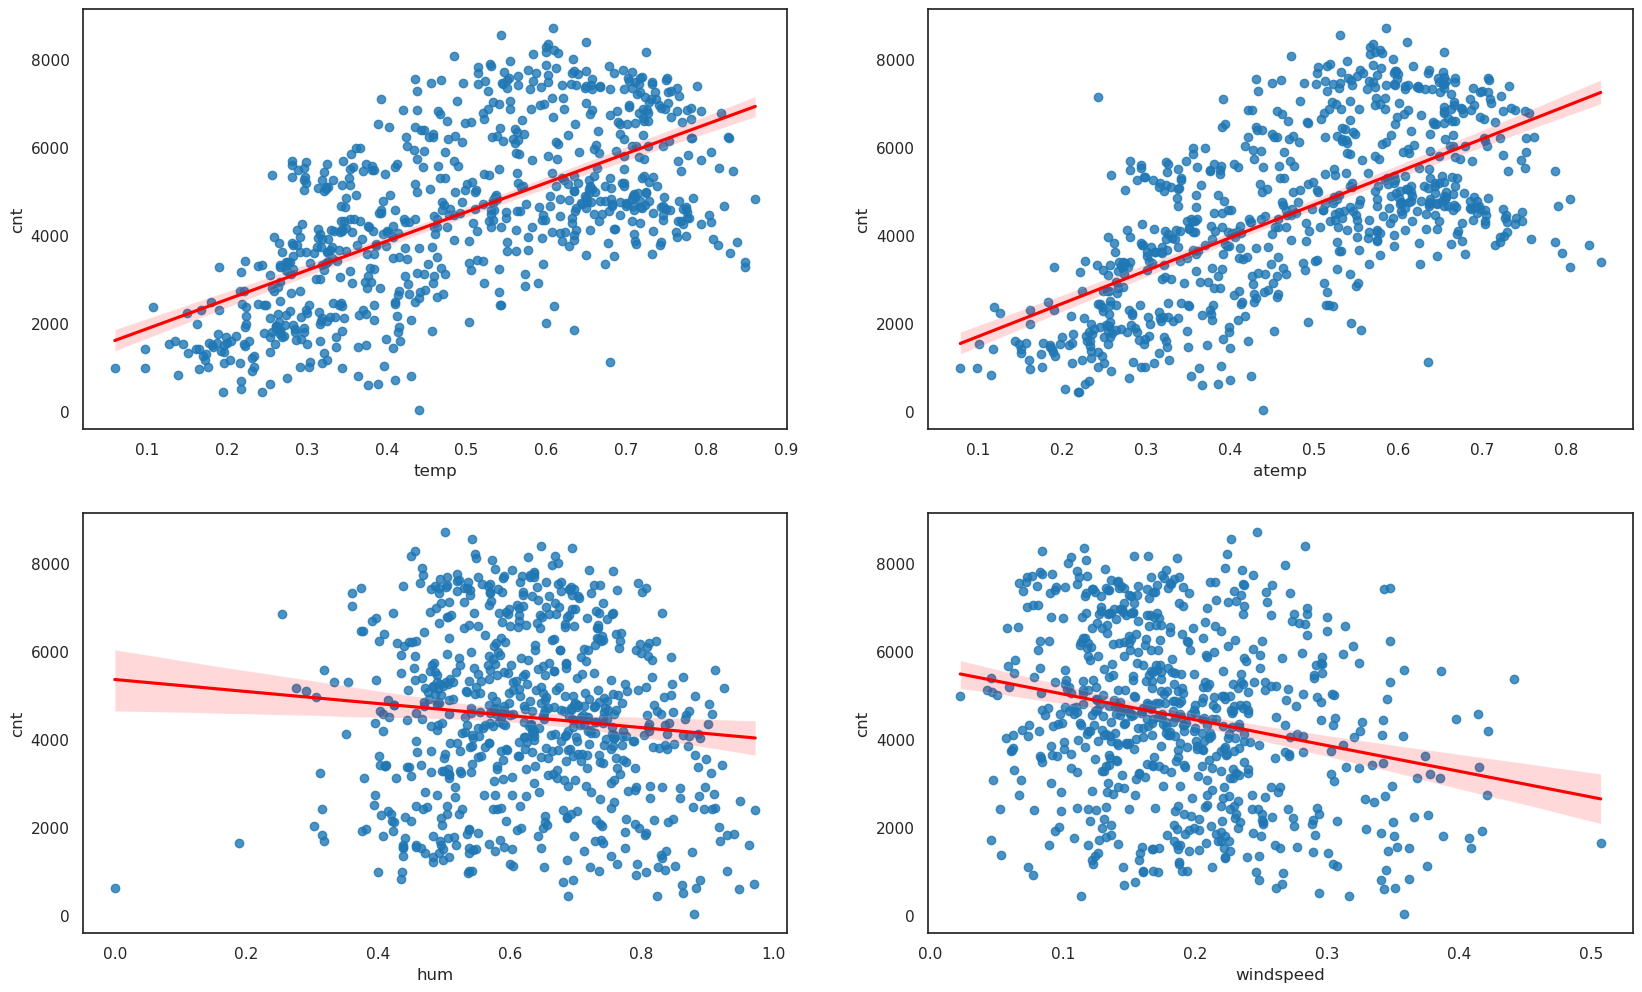

In [ ]:
col = ["temp", "atemp", "hum", "windspeed"]
plt.figure(figsize=[20, 12])
for i in enumerate(col):
    plt.subplot(2, 2, i[0] + 1)
    sns.regplot(data=raw_dataset, x=i[1], y="cnt", line_kws={"color": "red"})

plt.show()

From this, we can infer that there is a positive correlation between `temp` and `atemp` and `cnt`. There is a negative correlation between `windspeed` and `hum` and `cnt`.


Similarly, we can perform a bivariate analysis on the categorical variables.


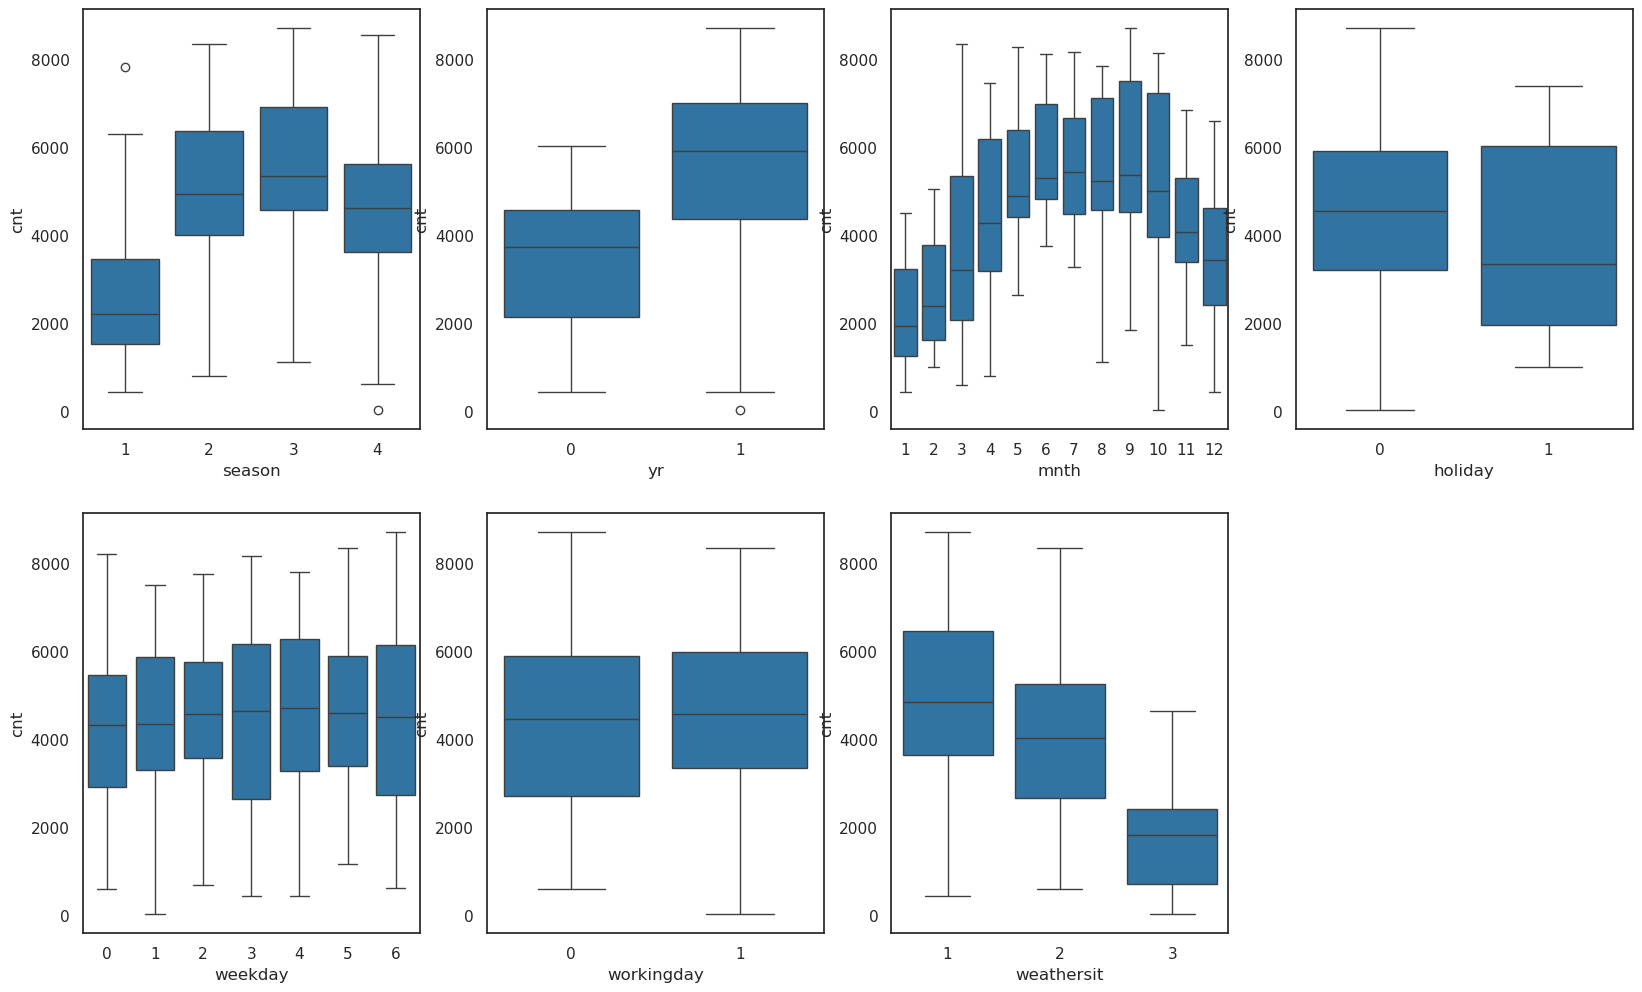

In [ ]:
col = ["season", "yr", "mnth", "holiday", "weekday", "workingday", "weathersit"]
plt.figure(figsize=[20, 12])
for i in enumerate(col):
    plt.subplot(2, 4, i[0] + 1)
    sns.boxplot(data=raw_dataset, x=i[1], y="cnt")

plt.show()

From this we infer that rental bike demands are the highest during Fall and lowest during Spring. There was an increase in demand in bikes in 2019 as compared to 2018. A higher demand for bikes is observed on non-holidays as compared to holidays. Lastly, when renting bikes, clear weather is preferred over light rain, thunderstorm and snowy days.


### **Data exploration: Multivariate analysis** <a id="toc-data-exploration-multivariate-analysis"></a>


We can perform multivariate analysis by creating a pairplot of all the columns in our dataset. 


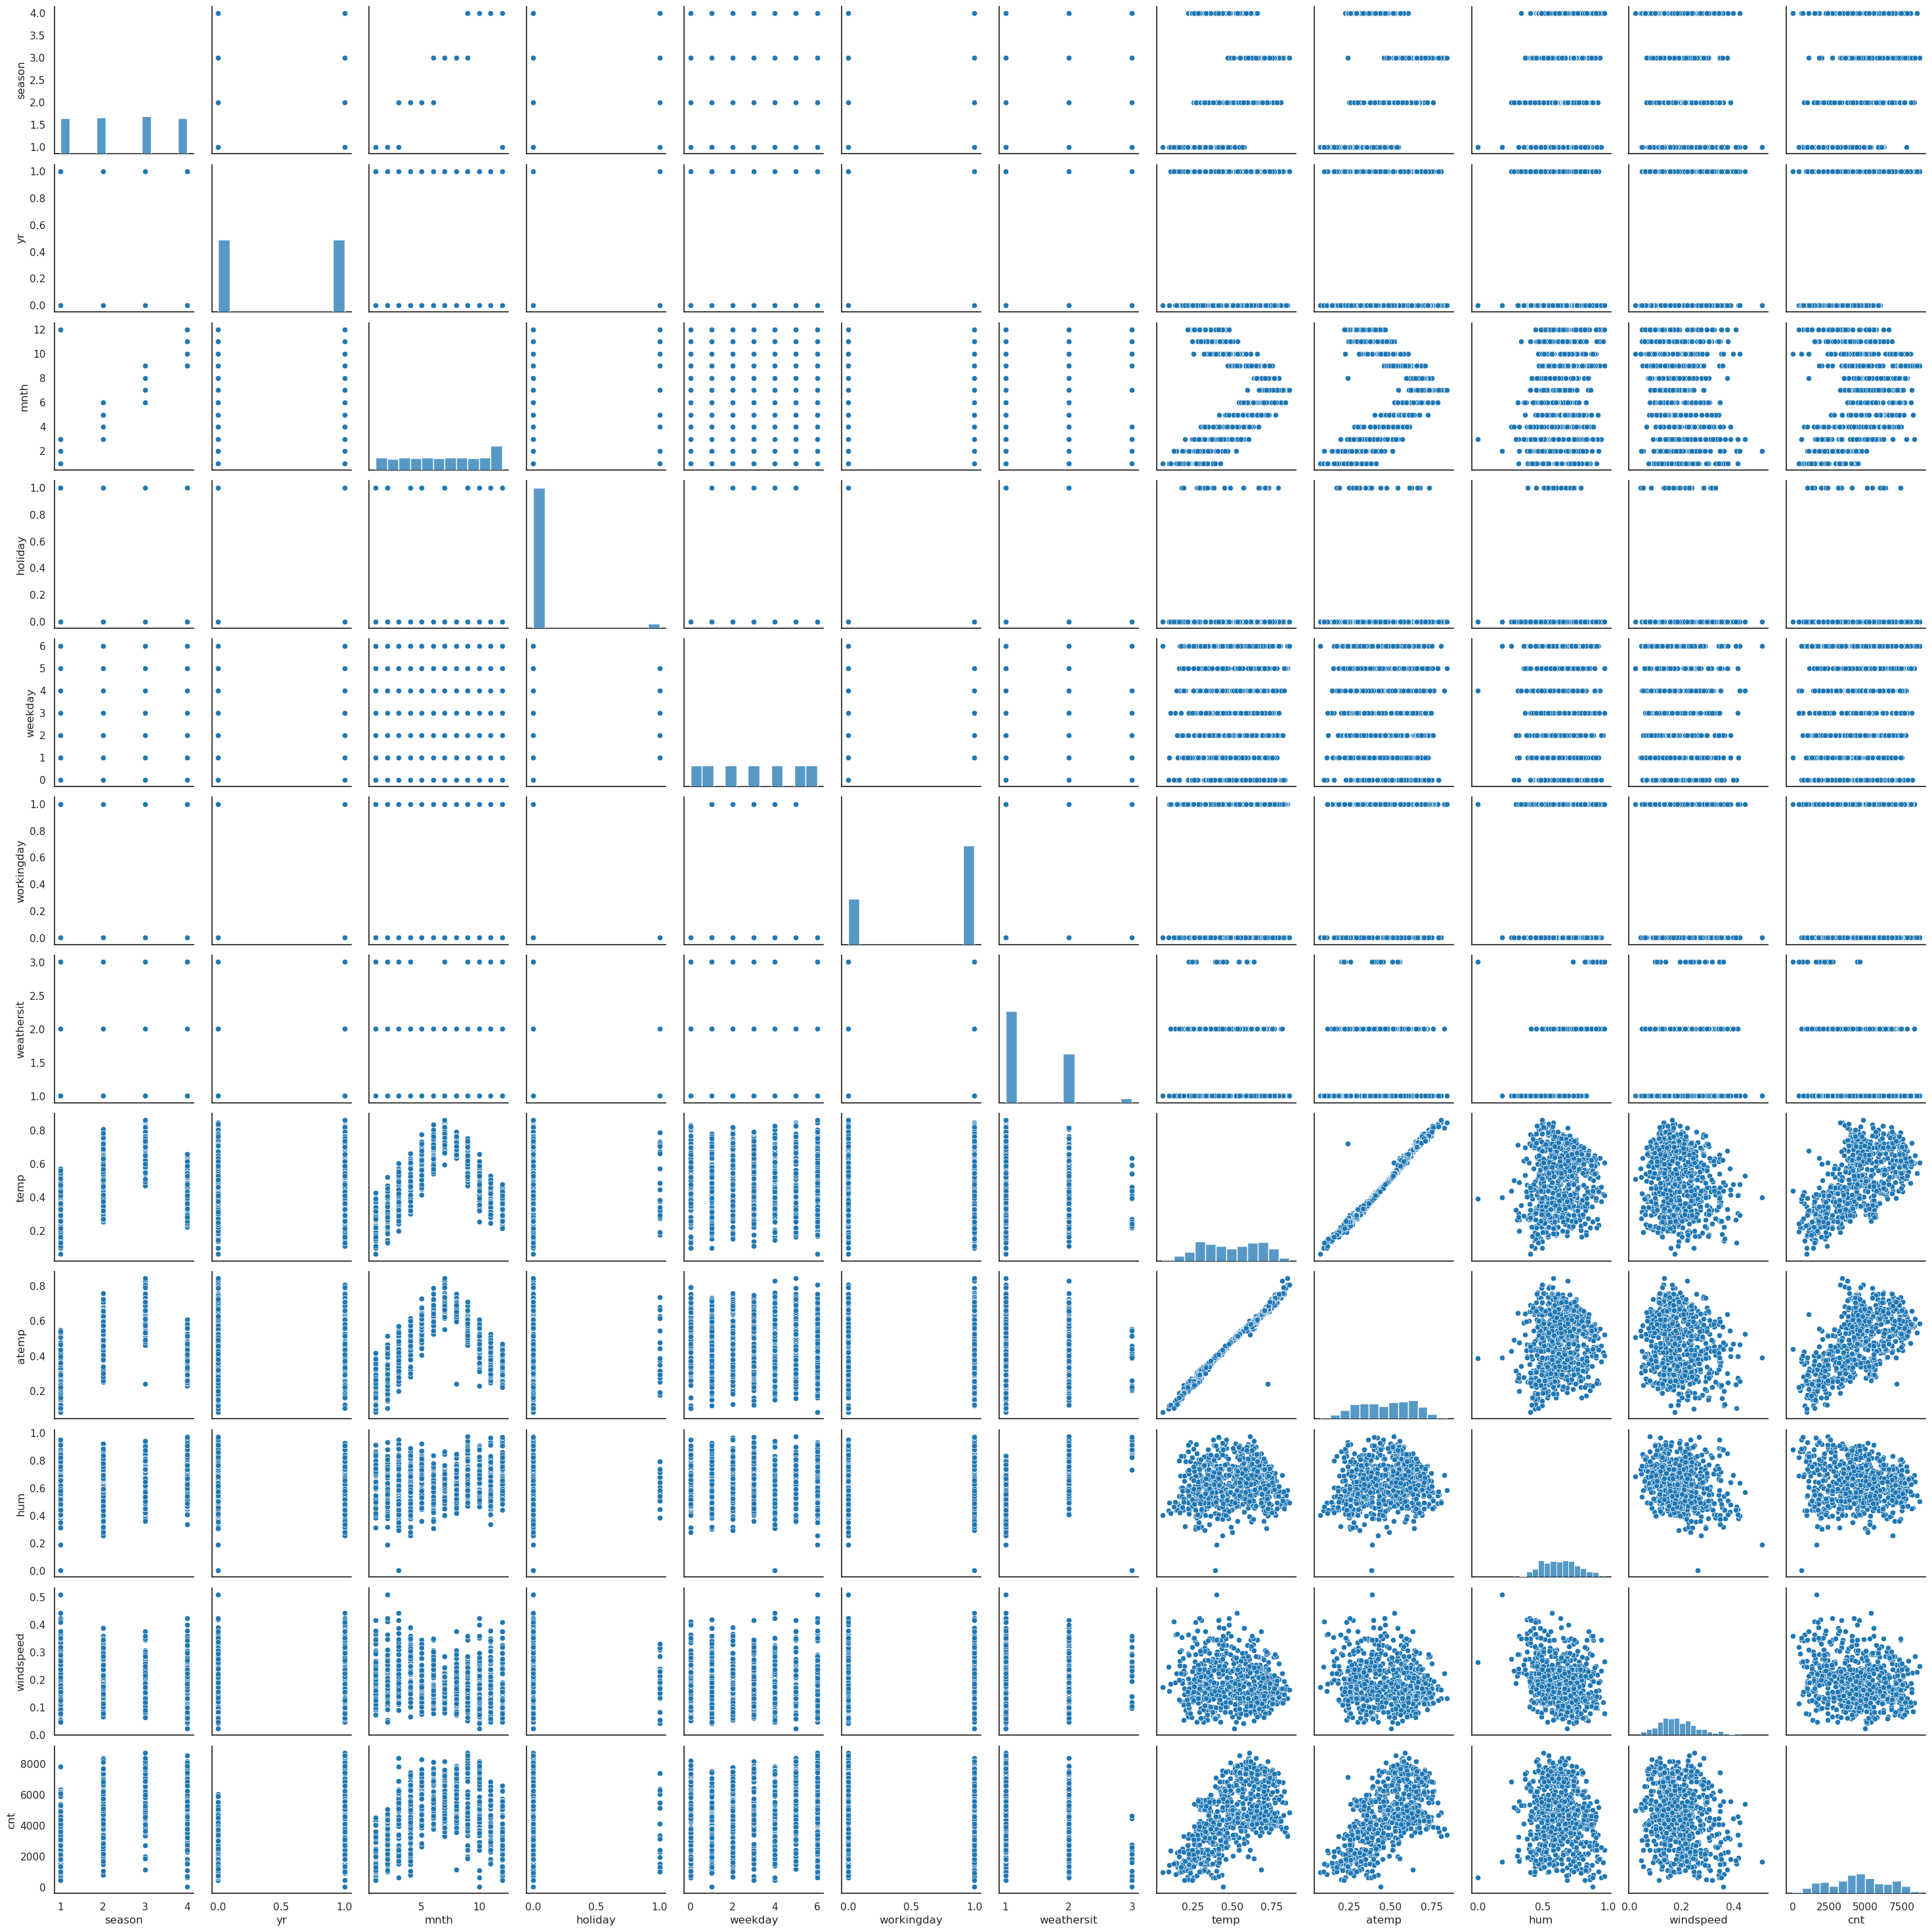

In [93]:
sns.pairplot(raw_dataset)

### **Data exploration: Heatmap of columns** <a id="toc-data-exploration-heatmap-of-columns"></a>


Using a heatmap we can explore which variables are positively or negatively correlated with one another.


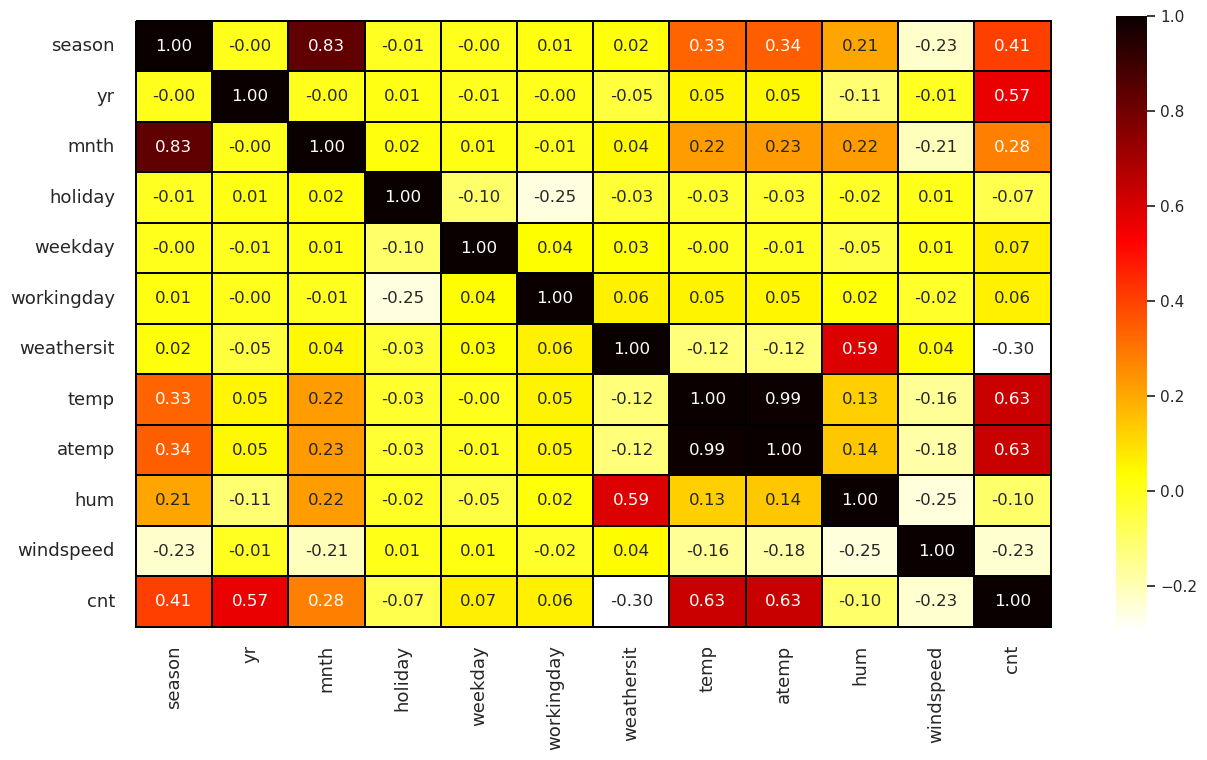

In [ ]:
plt.figure(figsize=[15, 8])
fig = sns.heatmap(
    raw_dataset.corr(),
    cmap="hot_r",
    annot=True,
    linecolor="black",
    linewidths=0.01,
    annot_kws={"fontsize": 12},
    fmt="0.2f",
)

top, bottom = fig.get_ylim()
fig.set_ylim(top + 0.1, bottom - 0.1)

left, right = fig.get_xlim()
fig.set_xlim(left - 0.1, right + 0.1)

plt.yticks(fontsize=13, rotation=0)
plt.xticks(fontsize=13, rotation=90)

From the heatmap, we can infer that `temp` and `atemp` are highly correlated with each other and with `cnt`.

A positive correlation between `temp`, `atemp`, `yr` and `cnt` exists, while a negative correlation between `windspeed`, `hum`, `weathersit`, `holiday` and `cnt` exists.


### **Split the data into training and test sets** <a id="toc-split-the-data-into-training-and-test-sets"></a>


Now we will split the data set into a training set and a test set using **Pandas**. This approach randomly selects 80% of the rows for training and uses the remaining 20% for testing. It is simple and works well for many tabular datasets.




In [95]:
train_dataset = raw_dataset.sample(frac=0.8, random_state=0)
test_dataset = raw_dataset.drop(train_dataset.index)

However, for structured tabular data stored in a Pandas DataFrame, many users still prefer using `scikit-learn` because it is simpler and more readable.

A more common and cleaner approach is to use `train_test_split` from `scikit-learn`:


In [ ]:
from sklearn.model_selection import train_test_split

train_dataset, test_dataset = train_test_split(
    raw_dataset, test_size=0.2, random_state=0
)

TensorFlow itself also provides methods for splitting data, especially when using `tf.data.Dataset`. For example:

```python
dataset = tf.data.Dataset.from_tensor_slices((features, labels))

train_size = int(0.8 * len(features))

train_dataset = dataset.take(train_size)
test_dataset = dataset.skip(train_size)
```

However, for most tabular machine learning workflows, `train_test_split` remains the most common and convenient approach.

### **Split features from labels** <a id="toc-split-features-from-labels"></a>


After splitting the dataset, we separate the target variable (`cnt`) from the input features:
Here:

- `train_features` and `test_features` contain the input variables
- `train_labels` and `test_labels` contain the target values to predict

In [ ]:
train_features = train_dataset.copy()
test_features = test_dataset.copy()

train_labels = train_features.pop("cnt")
test_labels = test_features.pop("cnt")

### **Normalization** <a id="toc-normalization"></a>



The features in this dataset use different numerical scales and ranges. For example, temperature, humidity, and wind speed all have different value distributions. Before training a linear regression model, it is generally good practice to normalize the input features.

In linear regression and neural networks, the input features are multiplied by model weights. If some features have much larger values than others, they can dominate the gradient updates during training. This may cause unstable training or slow convergence.

Although a model can still converge without normalization, feature normalization usually makes the optimization process more stable and efficient.

In this notebook, we will use `tf.keras.layers.Normalization` to normalize the input features. This layer automatically learns the mean and variance of the training data and standardizes the features during training.

We will create the normalization layer using:

```python
normalizer = tf.keras.layers.Normalization(axis=-1)
```

The argument `axis=-1` means that normalization is applied independently to each feature column along the last axis of the input tensor. In other words, the layer calculates a separate mean and variance for every input feature.

In [98]:
normalizer = tf.keras.layers.Normalization(axis=-1)

Now using `normalization.adapt`, we will fit the state of the pre-processing layer to the training data.

This will compute the mean and variance of the data and store them as the layer's weights.


In [99]:
normalizer.adapt(np.array(train_features))

Calculate the mean and variance:


In [100]:
print(normalizer.mean.numpy())
print(normalizer.variance.numpy())

[[2.510274   0.49657536 6.5445204  0.02739726 3.0017123  0.6917808
  1.3869863  0.4914575  0.47077307 0.6236887  0.18949275]]
[[1.2293465e+00 2.4998827e-01 1.1956922e+01 2.6646651e-02 3.9503396e+00
  2.1322012e-01 2.8859776e-01 3.3907048e-02 2.6891682e-02 1.9624034e-02
  5.8382102e-03]]


When the layer is called, it returns the input data, with each feature independently normalized. For example, let us look at the first input row:


In [101]:
print(np.array(train_features[:1]))

[[2.       0.       4.       0.       5.       1.       2.       0.335833
  0.324479 0.83625  0.226992]]


Now, let us look at the normalized input:


In [102]:
print(normalizer(np.array(train_features[:1])).numpy())

[[-0.46022075 -0.993174   -0.7358618  -0.16783626  1.0054045   0.66749126
   1.1411     -0.84514827 -0.89210856  1.517365    0.4907753 ]]


### **Linear regression with a single input** <a id="toc-linear-regression-with-a-single-input"></a>



We will begin by building a simple linear regression model to predict `cnt` using only the `temp` feature. We choose `temp` because it has a strong correlation with bike rental counts and is expected to be highly predictive.

The model will be created using `tf.keras.Sequential`, which allows us to stack layers in a simple linear order.

First, we apply the `tf.keras.layers.Normalization` layer created earlier to normalize the input feature. Feature normalization helps stabilize training and improves convergence during gradient descent.

Next, we use a linear layer:

```python
tf.keras.layers.Dense(units=1)
```

This layer performs the linear transformation:

$$
y = wx + b
$$

where:

- $w$ is the model weight
- $b$ is the bias term
- $y$ is the predicted output

Since this is a regression problem, the model produces a single continuous output value.

In Keras, the input shape can either be specified manually using the `input_shape` argument or inferred automatically when the model receives data for the first time.

Next, we create an array made of the `temp` features.


In [ ]:
temp = np.array(train_features["temp"])

Next, we create a `tf.keras.layers.Normalization` layer and fit it to the training data.
The normalization layer standardizes the input data before it is passed into the model. To do this, the layer must first learn the statistical properties of the dataset, such as the mean and variance. 

The `adapt()` function performs this step. TensorFlow scans the `temp` data and automatically calculates its mean and variance. These values are then stored inside the normalization layer.

Later, during training and prediction, the layer uses these stored statistics to normalize the input values automatically.


In [ ]:
temp_normalizer = layers.Normalization(
    input_shape=[
        1,
    ],
    axis=None,
)
temp_normalizer.adapt(temp)

Build the Keras model:


In [ ]:
temp_model = tf.keras.Sequential([temp_normalizer, layers.Dense(units=1)])
temp_model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ normalization_5 (Normalization) │ (None, 1)              │             3 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5 (24.00 B)

 Trainable params: 2 (8.00 B)

 Non-trainable params: 3 (16.00 B)


Before training the model, we must configure the training process using `model.compile()`.

The `loss` function measures the difference between the predicted values and the true values. During training, the model tries to minimize this error.

In this example, we use **Mean Squared Error (MSE)** as the loss function:

$$
MSE = \frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2
$$

where:

- $y_i$ is the true value
- $\hat{y}_i$ is the predicted value
- $n$ is the number of samples

Because the errors are squared, larger prediction errors are penalized more heavily.

The `optimizer` controls how the model updates its weights during training to reduce the loss. Here we use **Stochastic Gradient Descent (SGD)**:

The learning rate determines the step size used when updating the weights. A very large learning rate may make training unstable, while a very small learning rate may slow convergence.

In [ ]:
temp_model.compile(
    optimizer=tf.keras.optimizers.SGD(learning_rate=0.001),
    loss="mean_squared_error",
)

Using `keras.fit`, we train the model for 100 epochs.


In [107]:
%%time
history = temp_model.fit(
    train_features['temp'],
    train_labels,
    # to view the logs, uncomment this:
    verbose=False,
    epochs=100,
    # validation split: 20% of the training data.
    validation_split = 0.2)

CPU times: user 4 s, sys: 662 ms, total: 4.66 s
Wall time: 3.74 s


We can create a plot of loss on the training and validation datasets over training epochs.


In [ ]:
def plot_loss(history):
    plt.plot(history.history["loss"], label="loss")  # training loss
    plt.plot(history.history["val_loss"], label="val_loss")  # validation loss
    plt.legend()
    plt.grid(True)

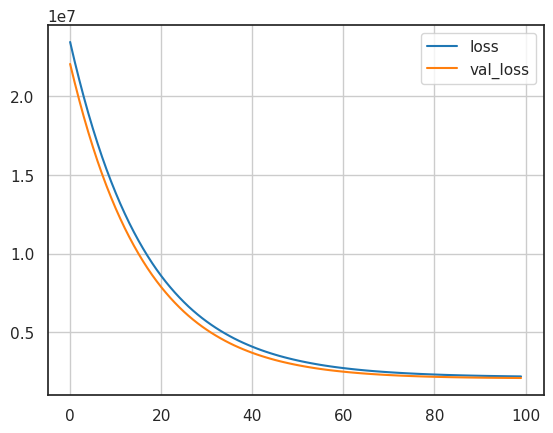

In [109]:
plot_loss(history)

Next, we will use `model.predict` to predict the `cnt` values in the test dataset, using just the `temp` feature values as input:


In [ ]:
y_pred = temp_model.predict(test_features["temp"])

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


We can compute the root mean squared error:


In [111]:
print(np.sqrt(metrics.mean_squared_error(test_labels, y_pred)))

1663.366015042991


Since this a single-variable linear regression, we can easily visualize the results:


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


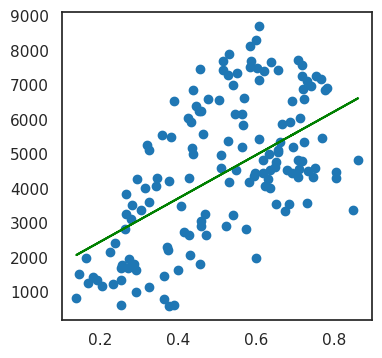

In [ ]:
plt.figure(figsize=(4, 4))
plt.plot(
    test_features["temp"],
    test_labels,
    "o",
    test_features["temp"],
    temp_model.predict(test_features["temp"]),
    "g",
)
plt.show()

### **Linear regression with multiple inputs** <a id="toc-linear-regression-with-multiple-inputs"></a>


We will create a similar setup to predict `cnt` based on multiple inputs. In this case, in our $y = mx+b$ equation, $m$ will be a matrix and $b$ will be a vector.

Similar to what we did before, the Sequential model will have `normalizer` as the first layer, and `Dense` as the second layer:


In [ ]:
linear_model = tf.keras.Sequential([normalizer, layers.Dense(units=1)])

We will compile the model using `complie()` and train the model on 100 epochs using `fit()`:


In [ ]:
linear_model.compile(
    optimizer=tf.keras.optimizers.SGD(learning_rate=0.001),
    loss="mean_squared_error",
)

In [115]:
%%time
history = linear_model.fit(
    train_features,
    train_labels,
    epochs=100,
    # to view the logs, uncomment this:
    verbose=0,
    # validation split: 20% of the training data.
    validation_split = 0.2)

CPU times: user 3.93 s, sys: 647 ms, total: 4.58 s
Wall time: 3.68 s


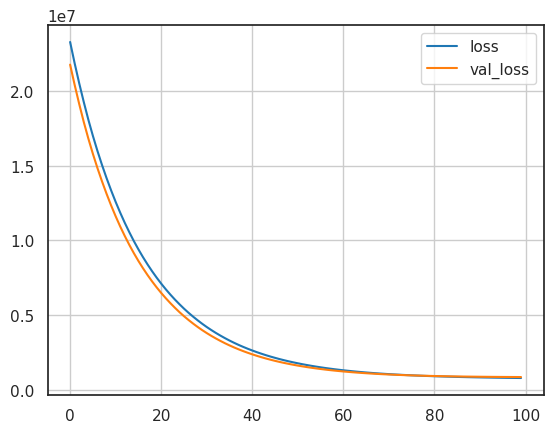

In [116]:
plot_loss(history)

We can see that with all the inputs in the regression model, it achieves a much lower training and validation error, and RMSE than the `temp_model` that had just one input.


In [ ]:
y_pred = linear_model.predict(test_features)
print(np.sqrt(metrics.mean_squared_error(test_labels, y_pred)))

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
970.9166738191285


`get_weights` returns a list consisting of NumPy arrays. The first array gives the weights of the layer and the second array gives the biases.


In [ ]:
# Print column names for reference
print("Column names")
print(test_features.columns)

# Print weights and biases for each layer
for layer in linear_model.layers:
    print("Layer Name:", layer.name)
    print("---")
    print("Weights")
    print("Shape:", layer.get_weights()[0].shape, "\n", layer.get_weights()[0])
    print("---")
    print("Bias")
    print(
        "Shape:",
        layer.get_weights()[1].shape,
        "\n",
        layer.get_weights()[1],
        "\n",
    )

Column names
Index(['season', 'yr', 'mnth', 'holiday', 'weekday', 'workingday',
       'weathersit', 'temp', 'atemp', 'hum', 'windspeed'],
      dtype='object')
Layer Name: normalization_4
---
Weights
Shape: (11,) 
 [2.510274   0.49657536 6.5445204  0.02739726 3.0017123  0.6917808
 1.3869863  0.4914575  0.47077307 0.6236887  0.18949275]
---
Bias
Shape: (11,) 
 [1.2293465e+00 2.4998827e-01 1.1956922e+01 2.6646651e-02 3.9503396e+00
 2.1322012e-01 2.8859776e-01 3.3907048e-02 2.6891682e-02 1.9624034e-02
 5.8382102e-03] 

Layer Name: dense_9
---
Weights
Shape: (11, 1) 
 [[ 295.97415 ]
 [ 944.8739  ]
 [  87.86111 ]
 [ -66.94433 ]
 [ 143.3034  ]
 [  43.292675]
 [-244.85019 ]
 [ 500.02432 ]
 [ 539.5676  ]
 [-229.79187 ]
 [-263.4193  ]]
---
Bias
Shape: (1,) 
 [4291.383] 



From the model weights, we can see that, similar to what we had seen in our heatmap, `yr`, `temp` and `atemp` have the highest model weights, and hence contribute the most the `cnt` predictions.


## **Using Neural Networks for Linear Regression** <a id="toc-using-neural-networks-for-linear-regression"></a>


In this section, we will use a Neural Network architecture in Keras to perform simple linear regression.


Let us begin by reading our univariate dataset. We will use the Iowa Housing dataset where the only feature is SquareFeet, and the target value is SalePrice.


We will reserve the last 500 data points for testing purposes.


In [ ]:
df = pd.read_csv(
    "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML311-Coursera/labs/Module1/L2/data/IowaHousingPrices.csv"
)

x_train = df[["SquareFeet"]].values[1:-500]
y_train = df[["SalePrice"]].values[1:-500]
x_test = df[["SquareFeet"]].values[-500:]
y_test = df[["SalePrice"]].values[-500:]

Now, we'll define the model configuration parameters. Since we're dealing with a univariate dataset, both our input and output sizes are 1. The learning rate is selected arbitrarily, where the goal is to ensure the NN doesn't overfit to the training data, and is easily generalizable to unseen test sets. We will use mean squared error as the loss function, and train the model on 30 iterations.


In [ ]:
output_size = 1
hidden_layer = 500
input_size = 1
learning_rate = 0.51
loss_function = "mean_squared_error"
epochs = 30
batch_size = 10

We will create a `Sequential` model and add a Dense layer with a relu activation in the hidden layer with ```hidden_layer``` neurons. As we have one output the output layer will have a dimension of  one. 


In [ ]:
model = keras.Sequential()
model.add(keras.layers.Dense(hidden_layer, activation="relu"))

model.add(keras.layers.Dense(output_size))

Next, we will compile and fit the model based on the configuration parameters defined earlier.


In [122]:
model.compile(keras.optimizers.Adam(learning_rate=learning_rate), loss_function)

In [ ]:
model.fit(x_train, y_train, epochs=epochs, batch_size=batch_size)

Epoch 1/30


96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 374us/step - loss: 5989541888.0000  
Epoch 2/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 323us/step - loss: 3714342400.0000
Epoch 3/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 327us/step - loss: 5055252992.0000
Epoch 4/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 335us/step - loss: 3256498432.0000
Epoch 5/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 314us/step - loss: 3952646656.0000
Epoch 6/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 324us/step - loss: 3518855936.0000
Epoch 7/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 308us/step - loss: 3326833408.0000
Epoch 8/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 319us/step - loss: 3405323520.0000
Epoch 9/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 322us/step - loss: 3309605632.0000
Epoch 10/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 318us/step - loss: 3524429056.0000
Epoch 11/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 304us/step - loss: 3482914816.0000
Epoch 12/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 327us/step - loss: 3131751168.0000
Epoch 13/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 325us/step - loss: 3422778368.0000
Epoch 14/30
96/96

Let us predict the sales prices on the full range of the test set and plot the result.


In [ ]:
x = np.arange(x_test.min(), x_test.max(), 10).reshape(-1, 1)

In [125]:
y_pred = model.predict(x)

17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


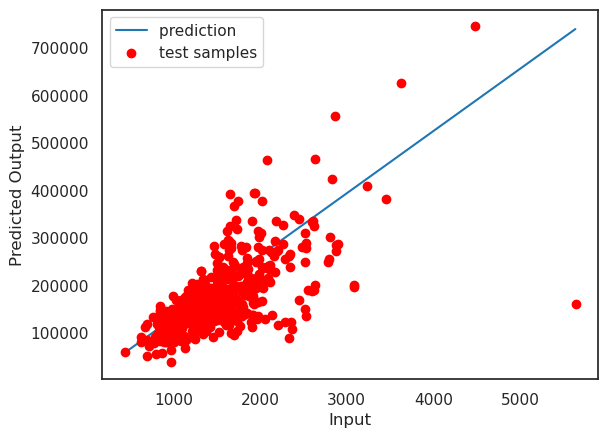

In [ ]:
plt.plot(x, y_pred, label="prediction ")
plt.plot(x_test, y_test, "ro", label="test samples")
plt.xlabel("Input")
plt.ylabel("Predicted Output")
plt.legend()
plt.show()

The model performs relatively well on the test set.


## **Exercises** <a id="toc-exercises"></a>


In this section, you will train a linear regression model in Keras. We will be using the classic Auto MPG dataset, and predict the fiel efficiency of automobiles.


### **Exercise 1 - Loading a dataset (Auto MPG)** <a id="toc-exercise-1-loading-a-dataset-auto-mpg"></a>


The dataset is again found in the UCI Machine Learning Repository. You can download it from [here](http://archive.ics.uci.edu/ml/machine-learning-databases/auto-mpg/auto-mpg.data?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMDeveloperSkillsNetworkML311Coursera747-2022-01-01). 


In [ ]:
# Write your solution here:

url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML311-Coursera/labs/Module1/L2/data/auto-mpg.data"
column_names = [
    "MPG",
    "Cylinders",
    "Displacement",
    "Horsepower",
    "Weight",
    "Acceleration",
    "Model Year",
    "Origin",
]

raw_dataset = pd.read_csv(
    url,
    names=column_names,
    na_values="?",
    comment="\t",
    sep=" ",
    skipinitialspace=True,
)

### **Exercise 2 - Clean the data** <a id="toc-exercise-2-clean-the-data"></a>


Drop all the rows that have NA values, and remove the `origin` column as it is categorical.


In [ ]:
# Write your solution here

dataset = raw_dataset.dropna()
dataset = dataset.drop(columns=["Origin"])

### **Exercise 3 - Split the data** <a id="toc-exercise-3-split-the-data"></a>


Split the data into training and test, and split the target from features.


In [ ]:
# Write your solution here
train_dataset = dataset.sample(frac=0.8, random_state=0)
test_dataset = dataset.drop(train_dataset.index)

train_features = train_dataset.copy()
test_features = test_dataset.copy()

train_labels = train_features.pop("MPG")
test_labels = test_features.pop("MPG")

### **Exercise 4 - Create a normalization layer** <a id="toc-exercise-4-create-a-normalization-layer"></a>


Next, use `tf.keras.layers.Normalization` to add feature normalization to the model. Using `normalization.adapt`, fit the state of the pre-processing layer to the training data. Calculate and print the mean and variance.


In [130]:
# Write your solution here
normalizer = tf.keras.layers.Normalization(axis=-1)
normalizer.adapt(np.array(train_features))
print(normalizer.mean.numpy())
print(normalizer.variance.numpy())

[[   5.477707  195.31847   104.86943  2990.2517     15.559236   75.89809 ]]
[[2.8800762e+00 1.0850414e+04 1.4466995e+03 7.0989681e+05 7.7550263e+00
  1.3467321e+01]]


### **Exercise 5 - Linear regression with multiple inputs** <a id="toc-exercise-5-linear-regression-with-multiple-inputs"></a>


Create a linear regression model to predict `MPG` based on all inputs in the dataset. In this case, in our $y = mx+b$ equation, $m$ will be a matrix and $b$ will be a vector.

Similar to what we did before, the Sequential model will have `normalizer` as the first layer, and `Dense` as the second layer. Compile and train the model, and plot the training history.


In [ ]:
# Write your solution here
linear_model = tf.keras.Sequential([normalizer, layers.Dense(units=1)])
linear_model.compile(
    optimizer=tf.keras.optimizers.SGD(learning_rate=0.001),
    loss="mean_squared_error",
)

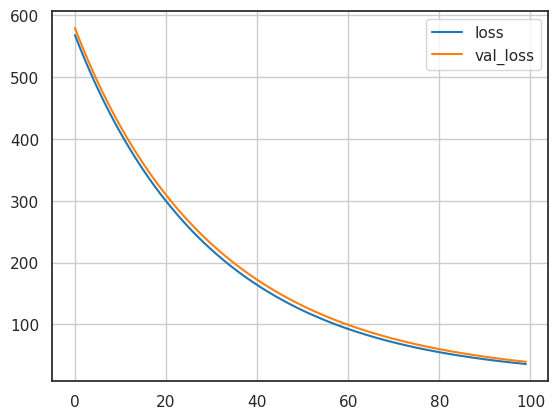

In [ ]:
history = linear_model.fit(
    train_features,
    train_labels,
    epochs=100,
    # to view the logs, uncomment this:
    verbose=0,
    # validation split: 20% of the training data.
    validation_split=0.2,
)

plot_loss(history)

In [139]:
linear_model.summary()

Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ normalization_6 (Normalization) │ (None, 6)              │            13 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 1)              │             7 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22 (96.00 B)

 Trainable params: 7 (28.00 B)

 Non-trainable params: 13 (56.00 B)

 Optimizer params: 2 (12.00 B)

Predict the output values of the test set, and compute the RMSE.


In [ ]:
# Write your solution here
y_pred = linear_model.predict(test_features)
print(np.sqrt(metrics.mean_squared_error(test_labels, y_pred)))

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
5.993460488231818


## **Authors**


[Kopal Garg](https://www.linkedin.com/in/gargkopal/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMDeveloperSkillsNetworkML311Coursera747-2022-01-01) is a Data Scientist Intern at IBM, and a Masters student in Computer Science at the University of Toronto. 

Su Wu


## **Change Log**


|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|
|2022-07-06|0.1|Kopal|Create Lab|
|2022-08-09|0.2|Steve H.|QA pass|
|2022-07-06|0.1|Kopal|Create Lab|
|2022-08-09|0.2|Steve H.|QA pass|
|2026-05-18|0.2|Su W.|Documentation Edits|

Copyright © 2022 IBM Corporation. All rights reserved.
